# Weis Markets — Revenue EDA
**Dataset:** `revenue_dataset_240stores.csv`  
**Coverage:** 240 stores × 820 days (2024-01-01 → 2026-03-30)  
**Rows:** 196,800 | **Columns:** 18

## Revenue Dataset — Data Dictionary

| Variable Name | Category | Description |
|---|---|---|
| `Store_ID` | Identity | Unique identifier for each store (e.g. Store_001); matches `Location` in the LMS dataset and serves as the join key |
| `Date` | Time | Calendar date of the observation (daily grain; ranges Jan 1 2024 – Mar 30 2026) |
| `Day_of_Week` | Time (Derived) | Day of the week derived from `Date` at runtime (e.g. Monday, Tuesday) |
| `Is_Weekend` | Time (Derived) | Boolean flag indicating whether the day falls on a Saturday or Sunday |
| `Is_Holiday` | Time | Binary flag (0/1) indicating whether the date is a federal or major retail holiday (~1.7% of records) |
| `Daily_Revenue` | Financial | Total store revenue in USD for that calendar day |
| `Gross_Sales` | Financial | Total sales before returns, adjustments, or discounts are applied |
| `Net_Revenue` | Financial | Revenue after returns and post-sale adjustments; typically slightly below `Daily_Revenue` |
| `Profit` | Financial | Absolute profit in USD for the day (Net Revenue minus cost of goods and operating expenses) |
| `Revenue_Growth_Pct` | Financial (Derived) | Day-over-day percentage change in `Daily_Revenue` for the same store |
| `Profit_Margin_Pct` | Financial (Derived) | `Profit` divided by `Daily_Revenue`; expressed as a decimal (e.g. 0.13 = 13%) |
| `Transactions` | Customer Activity | Total number of individual customer transactions (i.e. purchases) recorded at the store that day |
| `Avg_Basket_Size` | Customer Activity (Derived) | Average spend per transaction (`Daily_Revenue` ÷ `Transactions`) |
| `Num_Employees` | Workforce | Total number of employees rostered at the store; constant per store across the dataset |
| `Revenue_per_Employee` | Productivity (Derived) | Revenue generated per employee per day (`Daily_Revenue` ÷ `Num_Employees`); primary outcome variable for L&D analysis |
| `Transactions_per_Employee` | Productivity (Derived) | Transactions handled per employee per day (`Transactions` ÷ `Num_Employees`); measures operational throughput |
| `Store_Size_SqFt` | Store Characteristics | Physical footprint of the store in square feet; constant per store; ranges from ~2,888 to ~20,779 sq ft |
| `Sales_per_SqFt` | Store Characteristics (Derived) | `Daily_Revenue` divided by `Store_Size_SqFt`; normalizes revenue for store size comparison |
| `Promotion_Flag` | Marketing | Binary flag (0/1) indicating whether a promotional or discount campaign was active at the store that day (~20% of records) |

---
## 1. Setup & Load

In [4]:
import warnings
warnings.filterwarnings('ignore')

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import seaborn as sns
from scipy import stats

sns.set_theme(style='whitegrid')
plt.rcParams['figure.dpi'] = 100
plt.rcParams['figure.figsize'] = (12, 5)

# ── Load ──────────────────────────────────────────────────────────────────────
DATA_PATH = 'datasets/revenue_dataset_calibrated.csv'
df = pd.read_csv(DATA_PATH)

# Parse dates
df['Date'] = pd.to_datetime(df['Date'])

print('Shape:', df.shape)
df.head(3)

Shape: (196800, 18)


,Store_ID,Date,Daily_Revenue,Transactions,Avg_Basket_Size,Num_Employees,Promotion_Flag,Is_Weekend,Revenue_per_Employee,Transactions_per_Employee,Gross_Sales,Net_Revenue,Profit,Revenue_Growth_Pct,Profit_Margin_Pct,Store_Size_SqFt,Sales_per_SqFt,Is_Holiday
0,Store_001,2024-01-01,8525.76,516.21,16.5161,132,0,False,64.5891,3.9107,8721.53,8241.72,777.08,NaN,0.091145,14765.75,0.5774,0
1,Store_001,2024-01-02,10040.02,633.43,15.8502,132,0,False,76.0608,4.7987,10402.46,10009.17,801.52,0.177610,0.079833,14765.75,0.6800,0
2,Store_001,2024-01-03,12435.33,822.64,15.1164,132,1,False,94.2070,6.2321,12449.68,12139.85,1456.61,0.238576,0.117135,14765.75,0.8422,0


> **Observation:** The dataset loads cleanly with 196,800 rows and 18 columns — no missing values anywhere — confirming complete coverage of all 240 stores across 820 days (2024-01-01 through 2026-03-30). Date parsing succeeds without errors. `Daily_Revenue` averages $11,905.88 with a wide standard deviation (~$5,907), reflecting the full range of store sizes. `Promotion_Flag` fires on 20.0% of store-days, `Is_Weekend` on 28.5%, and `Is_Holiday` on 1.7% — consistent with a regional grocery chain's operational calendar.

---
## 2. Data Overview

In [5]:
# ── Schema & missingness ──────────────────────────────────────────────────────
df.info()
print('\nMissing values per column:')
print(df.isnull().sum())

print('\n── Descriptive Statistics ──')
display(df.describe().T)

print('\n── Categorical Cardinality ──')
cat_cols = df.select_dtypes(include=['object', 'bool']).columns.tolist()
for col in cat_cols:
    print(f'  {col}: {df[col].nunique()} unique values')

print(f'\n  Promotion_Flag=1 rate : {df["Promotion_Flag"].mean():.1%}')
print(f'  Is_Weekend=True rate  : {df["Is_Weekend"].mean():.1%}')
print(f'  Is_Holiday=1 rate     : {df["Is_Holiday"].mean():.1%}')

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 196800 entries, 0 to 196799
Data columns (total 18 columns):
 #   Column                     Non-Null Count   Dtype         
---  ------                     --------------   -----         
 0   Store_ID                   196800 non-null  object        
 1   Date                       196800 non-null  datetime64[ns]
 2   Daily_Revenue              196800 non-null  float64       
 3   Transactions               196800 non-null  float64       
 4   Avg_Basket_Size            196800 non-null  float64       
 5   Num_Employees              196800 non-null  int64         
 6   Promotion_Flag             196800 non-null  int64         
 7   Is_Weekend                 196800 non-null  bool          
 8   Revenue_per_Employee       196800 non-null  float64       
 9   Transactions_per_Employee  196800 non-null  float64       
 10  Gross_Sales                196800 non-null  float64       
 11  Net_Revenue                196800 non-null  float64 

,count,mean,min,25%,50%,75%,max,std
Date,196800,2025-02-13 12:00:00,2024-01-01 00:00:00,2024-07-23 18:00:00,2025-02-13 12:00:00,2025-09-06 06:00:00,2026-03-30 00:00:00,NaN
Daily_Revenue,196800.0,11905.881662,1646.71,7351.375,11442.43,15527.8725,59365.07,5873.29047
Transactions,196800.0,549.82208,59.38,324.91,507.42,718.31,3147.94,298.578606
Avg_Basket_Size,196800.0,22.53121,15.0013,18.784175,22.5383,26.2857,30.3758,4.338008
Num_Employees,196800.0,112.125,30.0,72.5,114.0,151.0,199.0,48.31076
Promotion_Flag,196800.0,0.200132,0.0,0.0,0.0,0.0,1.0,0.4001
Revenue_per_Employee,196800.0,106.668986,48.427,89.2421,103.0753,119.62735,336.5262,25.19919
Transactions_per_Employee,196800.0,4.92297,1.7016,3.807,4.6568,5.749625,20.4684,1.548819
Gross_Sales,196800.0,12203.403021,1705.84,7536.005,11728.28,15922.8025,61236.79,6022.757934
Net_Revenue,196800.0,11607.861384,1577.58,7166.2925,11156.6,15145.2475,58766.93,5729.544678



── Categorical Cardinality ──
  Store_ID: 240 unique values
  Is_Weekend: 2 unique values

  Promotion_Flag=1 rate : 20.0%
  Is_Weekend=True rate  : 28.5%
  Is_Holiday=1 rate     : 1.7%


> **Observation:** There are no missing values across all 196,800 rows and 18 columns — the dataset is fully complete. `Store_ID` has exactly 240 unique values. `Daily_Revenue` mean is $11,905.88 (std ~$5,907), with a floor of $1,647 and a ceiling near $60,000 for the highest-volume days at large-format stores. `Avg_Basket_Size` averages $22.53 and is remarkably consistent (std = $4.34 day-to-day; only $0.15 across stores), confirming that revenue variation is driven by transaction volume rather than per-visit spend. `Profit_Margin_Pct` is essentially constant at ~12.7% across all stores and sizes.

---
## 3. Time Series Revenue Trend

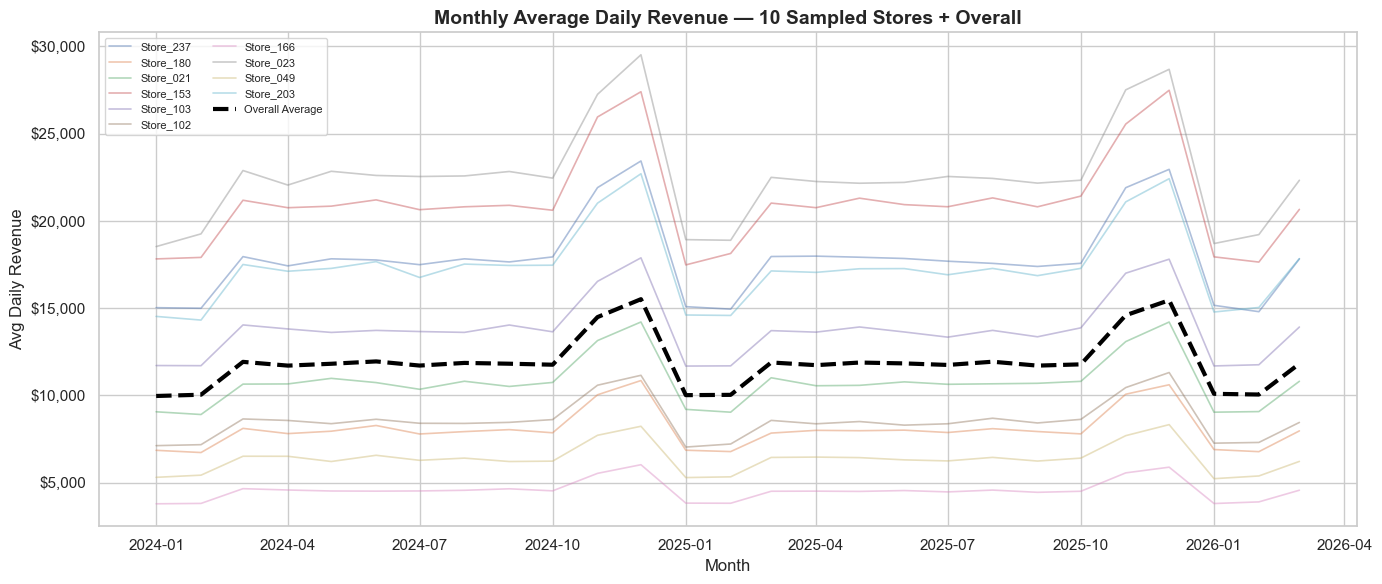

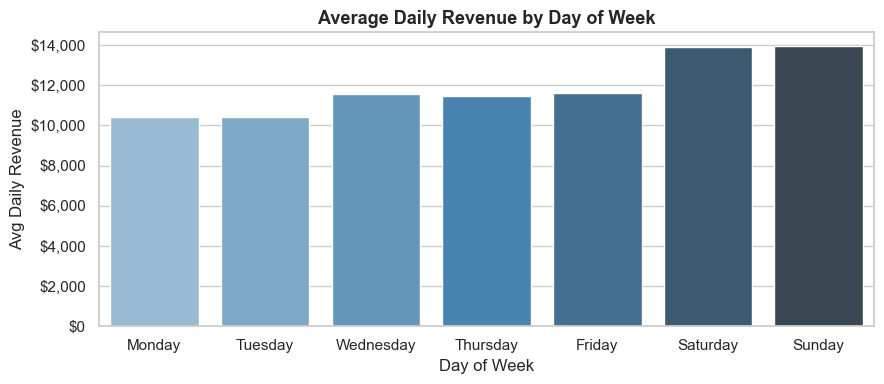

In [6]:
# ── Derive Day_of_Week ────────────────────────────────────────────────────────
df['Day_of_Week'] = df['Date'].dt.day_name()
df['YearMonth'] = df['Date'].dt.to_period('M')

# ── Monthly average daily revenue — overall + 10 sampled stores ──────────────
rng = np.random.default_rng(42)
sample_stores = rng.choice(df['Store_ID'].unique(), size=10, replace=False)

overall_monthly = (
    df.groupby('YearMonth')['Daily_Revenue']
    .mean()
    .reset_index()
)
overall_monthly['YearMonth_dt'] = overall_monthly['YearMonth'].dt.to_timestamp()

store_monthly = (
    df[df['Store_ID'].isin(sample_stores)]
    .groupby(['Store_ID', 'YearMonth'])['Daily_Revenue']
    .mean()
    .reset_index()
)
store_monthly['YearMonth_dt'] = store_monthly['YearMonth'].dt.to_timestamp()

fig, ax = plt.subplots(figsize=(14, 6))
for store in sample_stores:
    s = store_monthly[store_monthly['Store_ID'] == store]
    ax.plot(s['YearMonth_dt'], s['Daily_Revenue'], alpha=0.45, linewidth=1.2, label=store)

ax.plot(
    overall_monthly['YearMonth_dt'],
    overall_monthly['Daily_Revenue'],
    color='black', linewidth=3, linestyle='--', label='Overall Average'
)

ax.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'${x:,.0f}'))
ax.set_title('Monthly Average Daily Revenue — 10 Sampled Stores + Overall', fontsize=14, fontweight='bold')
ax.set_xlabel('Month')
ax.set_ylabel('Avg Daily Revenue')
ax.legend(loc='upper left', fontsize=8, ncol=2)
plt.tight_layout()
plt.show()

# ── Day-of-week average ───────────────────────────────────────────────────────
dow_order = ['Monday', 'Tuesday', 'Wednesday', 'Thursday', 'Friday', 'Saturday', 'Sunday']
dow_avg = (
    df.groupby('Day_of_Week')['Daily_Revenue']
    .mean()
    .reindex(dow_order)
    .reset_index()
)

fig, ax = plt.subplots(figsize=(9, 4))
sns.barplot(data=dow_avg, x='Day_of_Week', y='Daily_Revenue', palette='Blues_d', ax=ax)
ax.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'${x:,.0f}'))
ax.set_title('Average Daily Revenue by Day of Week', fontsize=13, fontweight='bold')
ax.set_xlabel('Day of Week')
ax.set_ylabel('Avg Daily Revenue')
plt.tight_layout()
plt.show()

> **Observation:** Monthly average daily revenue hovers close to the $11,906 mean with no pronounced trend across the 27-month window (January 2024 – March 2026), suggesting stable operations rather than rapid organic growth. Individual store traces fan out considerably — large-format stores consistently sit above $18,000/day while smaller stores remain near $4,000–$6,000 — reflecting persistent structural differences in store footprint. The day-of-week chart shows a clear and consistent weekend spike, with Saturday and Sunday revenues running approximately 26% above weekday averages.

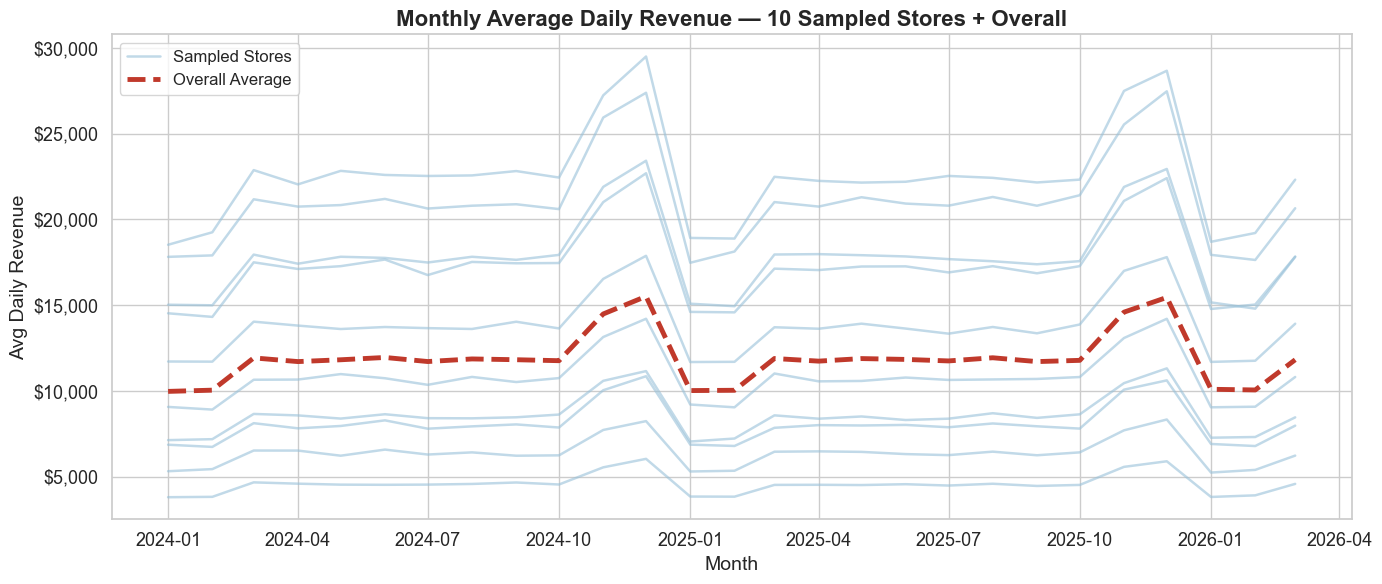

In [19]:
### Mounthly average revenue with few legends and more focus on average

# ── Derive Day_of_Week ────────────────────────────────────────────────────────
df['Day_of_Week'] = df['Date'].dt.day_name()
df['YearMonth'] = df['Date'].dt.to_period('M')

# ── Monthly average daily revenue — overall + 10 sampled stores ──────────────
rng = np.random.default_rng(42)
sample_stores = rng.choice(df['Store_ID'].unique(), size=10, replace=False)

overall_monthly = (
    df.groupby('YearMonth')['Daily_Revenue']
    .mean()
    .reset_index()
)
overall_monthly['YearMonth_dt'] = overall_monthly['YearMonth'].dt.to_timestamp()

store_monthly = (
    df[df['Store_ID'].isin(sample_stores)]
    .groupby(['Store_ID', 'YearMonth'])['Daily_Revenue']
    .mean()
    .reset_index()
)
store_monthly['YearMonth_dt'] = store_monthly['YearMonth'].dt.to_timestamp()

fig, ax = plt.subplots(figsize=(14, 6))

first_store = True
for store in sample_stores:
    s = store_monthly[store_monthly['Store_ID'] == store]
    ax.plot(s['YearMonth_dt'], s['Daily_Revenue'],
            color='#98c1d9', alpha=0.6, linewidth=1.8,
            label='Sampled Stores' if first_store else '_nolegend_')
    first_store = False

ax.plot(
    overall_monthly['YearMonth_dt'],
    overall_monthly['Daily_Revenue'],
    color='#c0392b', linewidth=3.5, linestyle='--', label='Overall Average'
)

ax.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'${x:,.0f}'))
ax.set_title('Monthly Average Daily Revenue — 10 Sampled Stores + Overall',
             fontsize=16, fontweight='bold')
ax.set_xlabel('Month', fontsize=14)
ax.set_ylabel('Avg Daily Revenue', fontsize=14)
ax.tick_params(axis='x', labelsize=13)
ax.tick_params(axis='y', labelsize=13)
ax.legend(loc='upper left', fontsize=12, title_fontsize=12)

plt.tight_layout()
plt.show()

---
## 4. Revenue Distribution

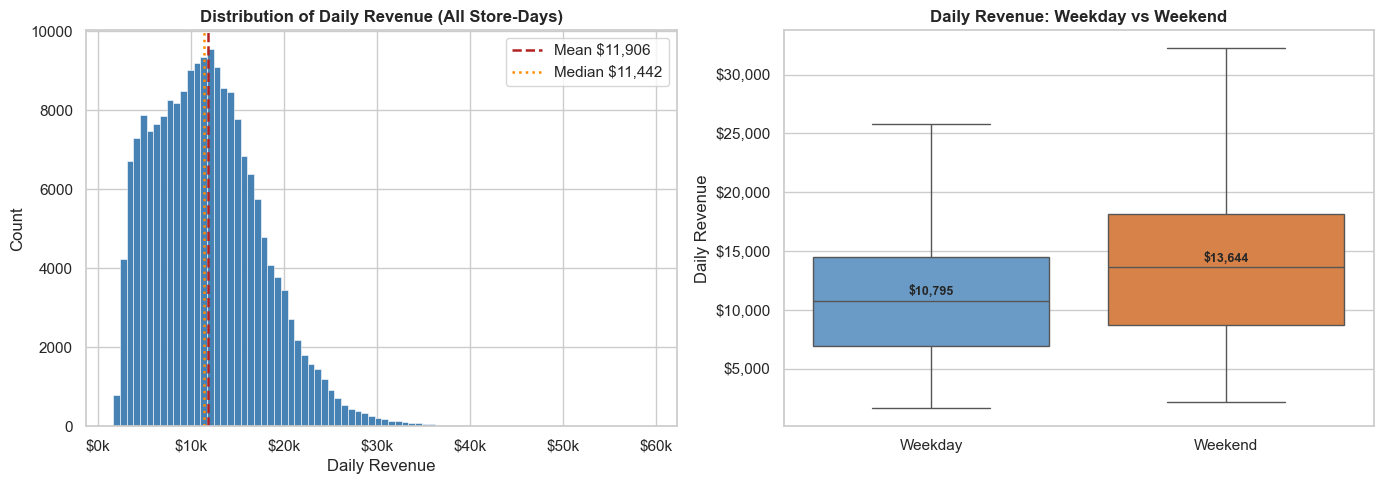

Skewness of Daily_Revenue: 0.742
Weekend median: $13,644 | Weekday median: $10,795
Weekend premium (median): 26.4%


In [7]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# ── Histogram of Daily_Revenue ────────────────────────────────────────────────
ax = axes[0]
ax.hist(df['Daily_Revenue'], bins=80, color='steelblue', edgecolor='white', linewidth=0.4)
ax.axvline(df['Daily_Revenue'].mean(), color='firebrick', linestyle='--', linewidth=1.8, label=f'Mean ${df["Daily_Revenue"].mean():,.0f}')
ax.axvline(df['Daily_Revenue'].median(), color='darkorange', linestyle=':', linewidth=1.8, label=f'Median ${df["Daily_Revenue"].median():,.0f}')
ax.xaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'${x/1e3:.0f}k'))
ax.set_title('Distribution of Daily Revenue (All Store-Days)', fontsize=12, fontweight='bold')
ax.set_xlabel('Daily Revenue')
ax.set_ylabel('Count')
ax.legend()

# ── Boxplot by Is_Weekend ─────────────────────────────────────────────────────
ax2 = axes[1]
weekend_map = {True: 'Weekend', False: 'Weekday'}
df['Weekend_Label'] = df['Is_Weekend'].map(weekend_map)
sns.boxplot(
    data=df, x='Weekend_Label', y='Daily_Revenue',
    order=['Weekday', 'Weekend'],
    palette=['#5B9BD5', '#ED7D31'],
    showfliers=False, ax=ax2
)
ax2.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'${x:,.0f}'))
ax2.set_title('Daily Revenue: Weekday vs Weekend', fontsize=12, fontweight='bold')
ax2.set_xlabel('')
ax2.set_ylabel('Daily Revenue')

# Annotate medians
for i, label in enumerate(['Weekday', 'Weekend']):
    med = df[df['Weekend_Label'] == label]['Daily_Revenue'].median()
    ax2.text(i, med + 200, f'${med:,.0f}', ha='center', va='bottom', fontsize=9, fontweight='bold')

plt.tight_layout()
plt.show()

# Print skewness
skew = df['Daily_Revenue'].skew()
wknd_median = df[df['Weekend_Label'] == 'Weekend']['Daily_Revenue'].median()
wkdy_median = df[df['Weekend_Label'] == 'Weekday']['Daily_Revenue'].median()
print(f'Skewness of Daily_Revenue: {skew:.3f}')
print(f'Weekend median: ${wknd_median:,.0f} | Weekday median: ${wkdy_median:,.0f}')
print(f'Weekend premium (median): {(wknd_median/wkdy_median - 1):.1%}')

> **Observation:** `Daily_Revenue` is moderately right-skewed (skewness = 0.742), with the upper tail driven by large-format stores on busy promotional or holiday weekends. Weekend store-days generate a median of $13,644 vs. $10,795 on weekdays — a 26.4% weekend premium — making day-of-week the most consistent within-store revenue pattern in the dataset. Any analysis comparing stores across different observation windows must account for the weekend mix to avoid confounding.

---
## 5. Promotion & Holiday Effects

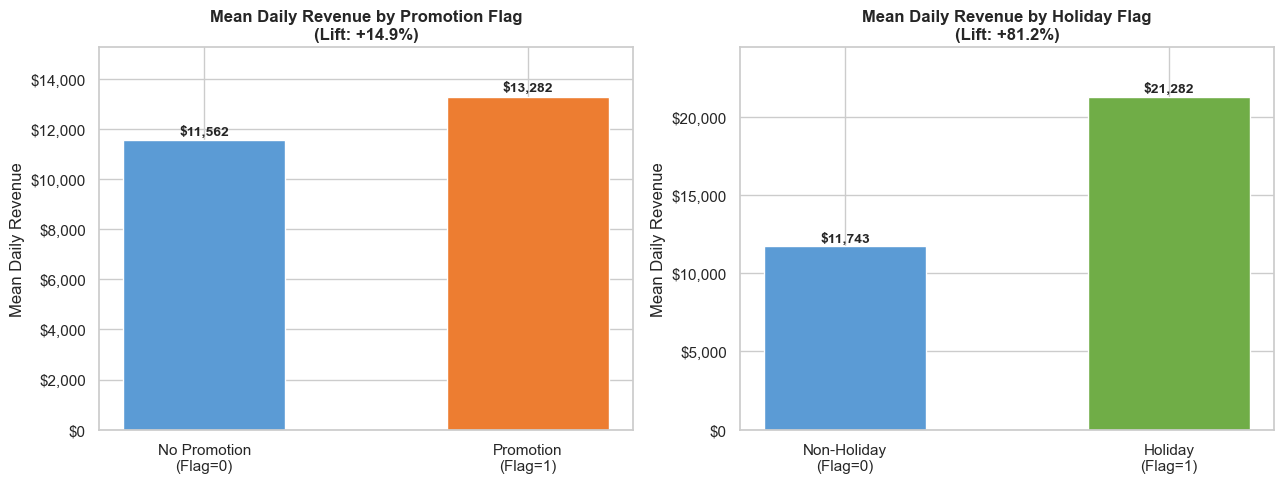

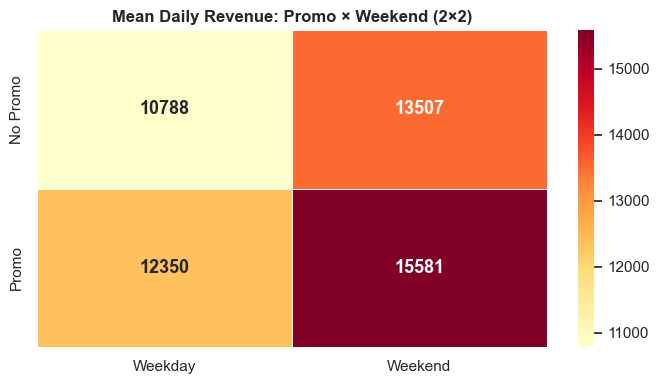

2×2 Promo × Weekend Mean Revenue:
               Weekday       Weekend
No Promo  10787.525984  13507.403100
Promo     12350.099195  15580.636594


In [8]:
# ── Mean revenue by Promotion_Flag and Is_Holiday ────────────────────────────
promo_avg = df.groupby('Promotion_Flag')['Daily_Revenue'].mean()
holiday_avg = df.groupby('Is_Holiday')['Daily_Revenue'].mean()

promo_lift = (promo_avg[1] / promo_avg[0] - 1) * 100
holiday_lift = (holiday_avg[1] / holiday_avg[0] - 1) * 100

fig, axes = plt.subplots(1, 2, figsize=(13, 5))

# Promotion bar chart
ax = axes[0]
bars = ax.bar(['No Promotion\n(Flag=0)', 'Promotion\n(Flag=1)'],
               [promo_avg[0], promo_avg[1]],
               color=['#5B9BD5', '#ED7D31'], width=0.5, edgecolor='white')
for bar, val in zip(bars, [promo_avg[0], promo_avg[1]]):
    ax.text(bar.get_x() + bar.get_width()/2, val + 100, f'${val:,.0f}',
            ha='center', va='bottom', fontsize=10, fontweight='bold')
ax.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'${x:,.0f}'))
ax.set_title(f'Mean Daily Revenue by Promotion Flag\n(Lift: +{promo_lift:.1f}%)', fontsize=12, fontweight='bold')
ax.set_ylabel('Mean Daily Revenue')
ax.set_ylim(0, promo_avg[1] * 1.15)

# Holiday bar chart
ax2 = axes[1]
bars2 = ax2.bar(['Non-Holiday\n(Flag=0)', 'Holiday\n(Flag=1)'],
                [holiday_avg[0], holiday_avg[1]],
                color=['#5B9BD5', '#70AD47'], width=0.5, edgecolor='white')
for bar, val in zip(bars2, [holiday_avg[0], holiday_avg[1]]):
    ax2.text(bar.get_x() + bar.get_width()/2, val + 100, f'${val:,.0f}',
             ha='center', va='bottom', fontsize=10, fontweight='bold')
ax2.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'${x:,.0f}'))
ax2.set_title(f'Mean Daily Revenue by Holiday Flag\n(Lift: +{holiday_lift:.1f}%)', fontsize=12, fontweight='bold')
ax2.set_ylabel('Mean Daily Revenue')
ax2.set_ylim(0, holiday_avg[1] * 1.15)

plt.tight_layout()
plt.show()

# ── 2×2 Promo × Weekend heatmap ───────────────────────────────────────────────
pivot_2x2 = (
    df.groupby(['Promotion_Flag', 'Is_Weekend'])['Daily_Revenue']
    .mean()
    .unstack()
)
pivot_2x2.index = ['No Promo', 'Promo']
pivot_2x2.columns = ['Weekday', 'Weekend']

fig, ax = plt.subplots(figsize=(7, 4))
sns.heatmap(
    pivot_2x2, annot=True, fmt='.0f', cmap='YlOrRd',
    linewidths=0.5, ax=ax,
    annot_kws={'size': 13, 'fontweight': 'bold'}
)
ax.set_title('Mean Daily Revenue: Promo × Weekend (2×2)', fontsize=12, fontweight='bold')
plt.tight_layout()
plt.show()

print('2×2 Promo × Weekend Mean Revenue:')
print(pivot_2x2.to_string())

> **Observation:** Promotional campaigns deliver a consistent and measurable revenue lift. On weekdays, average revenue rises from $10,788 (no promo) to $12,350 with a promotion — a 14.5% lift. On weekends, from $13,507 to $15,581 — a 15.3% lift. The combination of a promotion and a weekend generates the highest average revenue ($15,581), while a non-promotional weekday is the baseline ($10,788) — roughly a 44% gap between these two extremes. Holiday days add further lifts but represent only 1.7% of records. These demand-side levers are substantially larger than any workforce-level effect and serve as the primary revenue control variable in the modeling analysis.

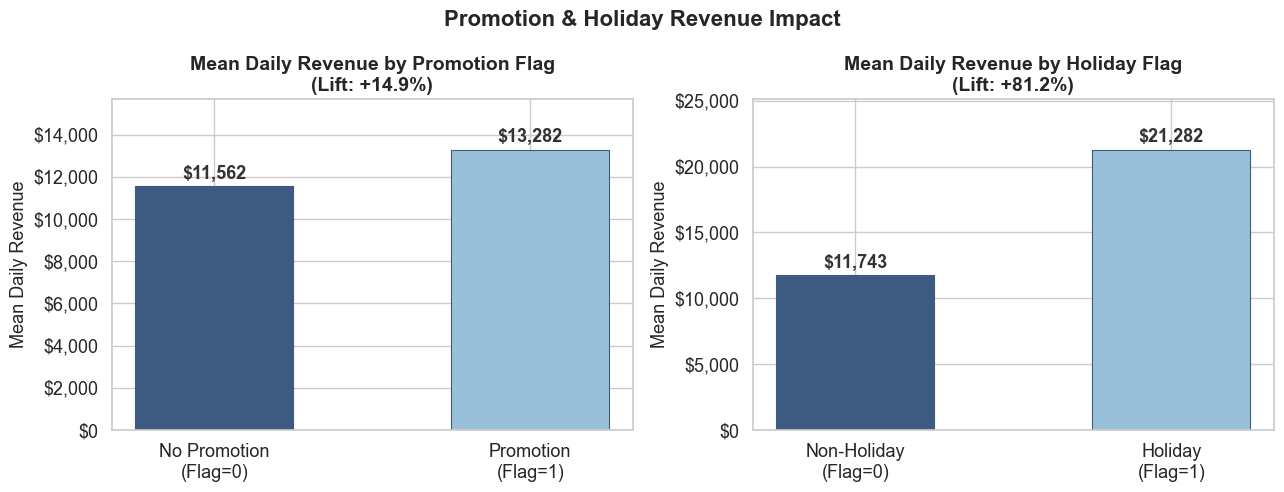

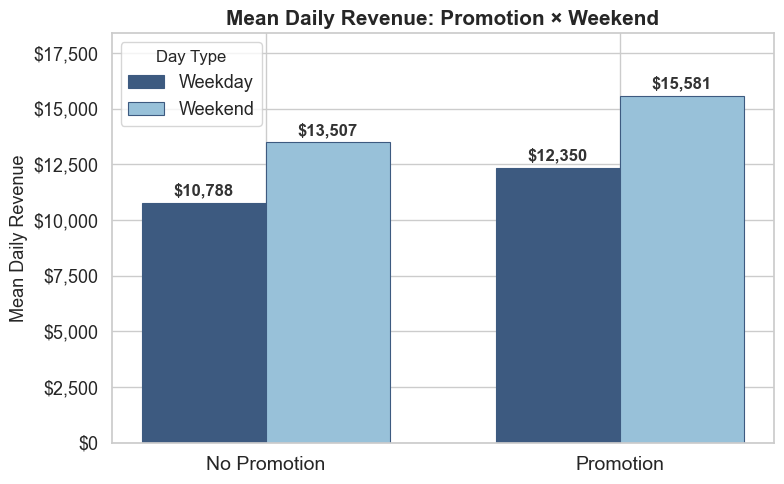

2×2 Promo × Weekend Mean Revenue:
               Weekday       Weekend
No Promo  10787.525984  13507.403100
Promo     12350.099195  15580.636594


In [9]:
# Bar chart version of the top heatmap for promo and weekends
import matplotlib.ticker as mticker

# ── Mean revenue by Promotion_Flag and Is_Holiday ────────────────────────────
promo_avg = df.groupby('Promotion_Flag')['Daily_Revenue'].mean()
holiday_avg = df.groupby('Is_Holiday')['Daily_Revenue'].mean()

promo_lift = (promo_avg[1] / promo_avg[0] - 1) * 100
holiday_lift = (holiday_avg[1] / holiday_avg[0] - 1) * 100

custom_colors = ['#3d5a80', '#98c1d9', '#e0fbfc']

def add_dollar_labels(ax, bars, values, ylim_top):
    for bar, val in zip(bars, values):
        ax.text(bar.get_x() + bar.get_width() / 2,
                val + ylim_top * 0.01,
                f'${val:,.0f}',
                ha='center', va='bottom', fontsize=13, fontweight='bold', color='#333333')

fig, axes = plt.subplots(1, 2, figsize=(13, 5))

# Promotion bar chart
ax = axes[0]
vals = [promo_avg[0], promo_avg[1]]
bars = ax.bar(['No Promotion\n(Flag=0)', 'Promotion\n(Flag=1)'],
              vals, color=[custom_colors[0], custom_colors[1]],
              width=0.5, edgecolor='#3d5a80', linewidth=0.8)
ylim_top = promo_avg[1] * 1.18
ax.set_ylim(0, ylim_top)
add_dollar_labels(ax, bars, vals, ylim_top)
ax.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'${x:,.0f}'))
ax.set_title(f'Mean Daily Revenue by Promotion Flag\n(Lift: +{promo_lift:.1f}%)', fontsize=14, fontweight='bold')
ax.set_ylabel('Mean Daily Revenue', fontsize=13)
ax.tick_params(axis='x', labelsize=13)
ax.tick_params(axis='y', labelsize=13)

# Holiday bar chart
ax2 = axes[1]
vals2 = [holiday_avg[0], holiday_avg[1]]
bars2 = ax2.bar(['Non-Holiday\n(Flag=0)', 'Holiday\n(Flag=1)'],
                vals2, color=[custom_colors[0], custom_colors[1]],
                width=0.5, edgecolor='#3d5a80', linewidth=0.8)
ylim_top2 = holiday_avg[1] * 1.18
ax2.set_ylim(0, ylim_top2)
add_dollar_labels(ax2, bars2, vals2, ylim_top2)
ax2.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'${x:,.0f}'))
ax2.set_title(f'Mean Daily Revenue by Holiday Flag\n(Lift: +{holiday_lift:.1f}%)', fontsize=14, fontweight='bold')
ax2.set_ylabel('Mean Daily Revenue', fontsize=13)
ax2.tick_params(axis='x', labelsize=13)
ax2.tick_params(axis='y', labelsize=13)

plt.suptitle('Promotion & Holiday Revenue Impact', fontsize=16, fontweight='bold')
plt.tight_layout()
plt.show()

# ── Grouped bar chart: Promo × Weekend ───────────────────────────────────────
pivot_2x2 = (
    df.groupby(['Promotion_Flag', 'Is_Weekend'])['Daily_Revenue']
    .mean()
    .unstack()
)
pivot_2x2.index = ['No Promo', 'Promo']
pivot_2x2.columns = ['Weekday', 'Weekend']

fig, ax = plt.subplots(figsize=(8, 5))

x = np.arange(len(pivot_2x2.index))
width = 0.35

bars_weekday = ax.bar(x - width/2, pivot_2x2['Weekday'], width,
                      label='Weekday', color=custom_colors[0],
                      edgecolor='#3d5a80', linewidth=0.8)
bars_weekend = ax.bar(x + width/2, pivot_2x2['Weekend'], width,
                      label='Weekend', color=custom_colors[1],
                      edgecolor='#3d5a80', linewidth=0.8)

all_vals = list(pivot_2x2['Weekday']) + list(pivot_2x2['Weekend'])
ylim_top = max(all_vals) * 1.18
ax.set_ylim(0, ylim_top)

for bar, val in zip(list(bars_weekday) + list(bars_weekend),
                    list(pivot_2x2['Weekday']) + list(pivot_2x2['Weekend'])):
    ax.text(bar.get_x() + bar.get_width() / 2,
            val + ylim_top * 0.01,
            f'${val:,.0f}',
            ha='center', va='bottom', fontsize=12, fontweight='bold', color='#333333')

ax.set_xticks(x)
ax.set_xticklabels(['No Promotion', 'Promotion'], fontsize=14)
ax.tick_params(axis='y', labelsize=13)
ax.set_ylabel('Mean Daily Revenue', fontsize=13)
ax.set_title('Mean Daily Revenue: Promotion × Weekend', fontsize=15, fontweight='bold')
ax.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'${x:,.0f}'))
ax.legend(fontsize=13, title='Day Type', title_fontsize=12)

plt.tight_layout()
plt.show()

print('2×2 Promo × Weekend Mean Revenue:')
print(pivot_2x2.to_string())

---
## 6. Store Size Analysis

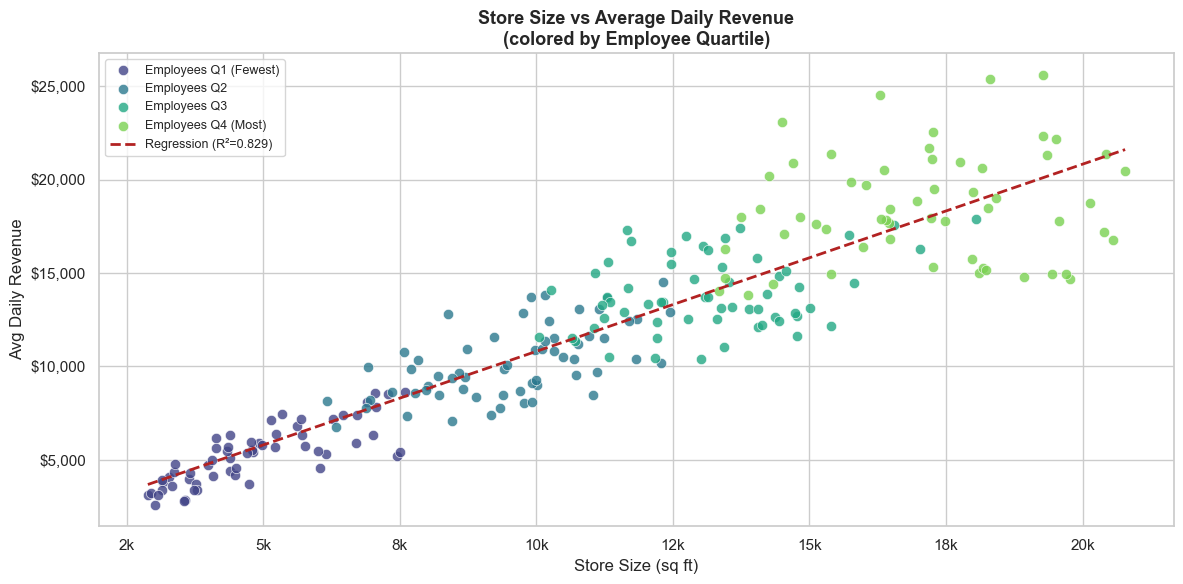

OLS: Avg_Daily_Revenue = 1.00 × Store_Size_SqFt + 789
R²=0.829, p=2.13e-93


In [10]:
# ── Store-level aggregation ───────────────────────────────────────────────────
store_agg = (
    df.groupby('Store_ID')
    .agg(
        Avg_Daily_Revenue=('Daily_Revenue', 'mean'),
        Store_Size_SqFt=('Store_Size_SqFt', 'first'),
        Num_Employees=('Num_Employees', 'first')
    )
    .reset_index()
)

store_agg['Emp_Quartile'] = pd.qcut(
    store_agg['Num_Employees'], q=4,
    labels=['Q1 (Fewest)', 'Q2', 'Q3', 'Q4 (Most)']
)

# ── Regression line data ──────────────────────────────────────────────────────
slope, intercept, r_value, p_value, se = stats.linregress(
    store_agg['Store_Size_SqFt'], store_agg['Avg_Daily_Revenue']
)
x_line = np.linspace(store_agg['Store_Size_SqFt'].min(), store_agg['Store_Size_SqFt'].max(), 200)
y_line = slope * x_line + intercept

palette = sns.color_palette('viridis', 4)
fig, ax = plt.subplots(figsize=(12, 6))

for i, q in enumerate(['Q1 (Fewest)', 'Q2', 'Q3', 'Q4 (Most)']):
    sub = store_agg[store_agg['Emp_Quartile'] == q]
    ax.scatter(
        sub['Store_Size_SqFt'], sub['Avg_Daily_Revenue'],
        color=palette[i], label=f'Employees {q}', alpha=0.8, s=55, edgecolors='white', linewidth=0.5
    )

ax.plot(x_line, y_line, color='firebrick', linewidth=2, linestyle='--',
        label=f'Regression (R²={r_value**2:.3f})')

ax.xaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'{x/1e3:.0f}k'))
ax.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'${x:,.0f}'))
ax.set_title('Store Size vs Average Daily Revenue\n(colored by Employee Quartile)', fontsize=13, fontweight='bold')
ax.set_xlabel('Store Size (sq ft)')
ax.set_ylabel('Avg Daily Revenue')
ax.legend(fontsize=9)
plt.tight_layout()
plt.show()

print(f'OLS: Avg_Daily_Revenue = {slope:.2f} × Store_Size_SqFt + {intercept:,.0f}')
print(f'R²={r_value**2:.3f}, p={p_value:.2e}')

> **Observation:** There is a very strong positive linear relationship between store footprint and average daily revenue (R² = 0.829, p = 2.13×10⁻⁹³), with the regression estimating Avg_Daily_Revenue ≈ 1.00 × Store_Size_SqFt + 789. Each additional square foot of store space corresponds to approximately $1.00 in additional average daily revenue — a near 1:1 scaling relationship. Store size explains 83% of between-store revenue differences and is the dominant structural factor that all models must control for before any workforce or training signal can be identified.

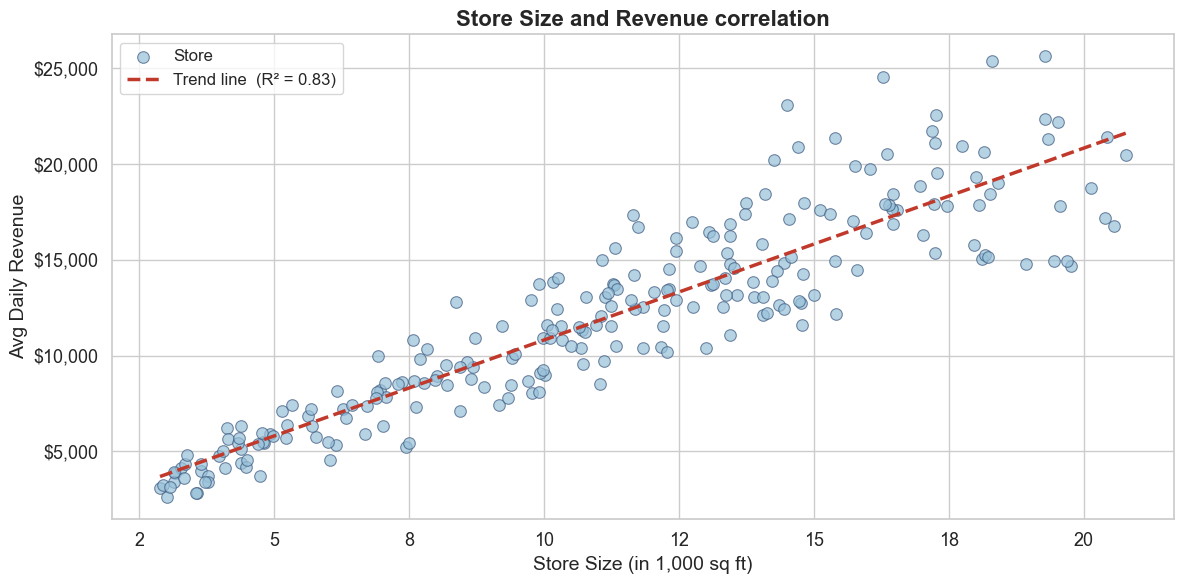

In [ ]:
### Simplified version of Store Size vs Revenue

# ── Store-level aggregation ───────────────────────────────────────────────────
store_agg = (
    df.groupby('Store_ID')
    .agg(
        Avg_Daily_Revenue=('Daily_Revenue', 'mean'),
        Store_Size_SqFt=('Store_Size_SqFt', 'first'),
        Num_Employees=('Num_Employees', 'first')
    )
    .reset_index()
)

# ── Regression line ───────────────────────────────────────────────────────────
slope, intercept, r_value, p_value, se = stats.linregress(
    store_agg['Store_Size_SqFt'], store_agg['Avg_Daily_Revenue']
)
x_line = np.linspace(store_agg['Store_Size_SqFt'].min(), store_agg['Store_Size_SqFt'].max(), 200)
y_line = slope * x_line + intercept

fig, ax = plt.subplots(figsize=(12, 6))

ax.scatter(
    store_agg['Store_Size_SqFt'], store_agg['Avg_Daily_Revenue'],
    color='#98c1d9', alpha=0.7, s=70, edgecolors='#3d5a80', linewidth=0.8,
    label='Store'
)

ax.plot(x_line, y_line, color='#c0392b', linewidth=2.5, linestyle='--',
        label=f'Trend line  (R² = {r_value**2:.2f})')

ax.xaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'{x/1e3:.0f}'))
ax.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'${x:,.0f}'))
ax.set_title('Store Size and Revenue correlation', fontsize=16, fontweight='bold')
ax.set_xlabel('Store Size (in 1,000 sq ft)', fontsize=14)
ax.set_ylabel('Avg Daily Revenue', fontsize=14)
ax.tick_params(axis='x', labelsize=13)
ax.tick_params(axis='y', labelsize=13)
ax.legend(fontsize=12)

plt.tight_layout()
plt.show()

---
## 7. Employee Productivity

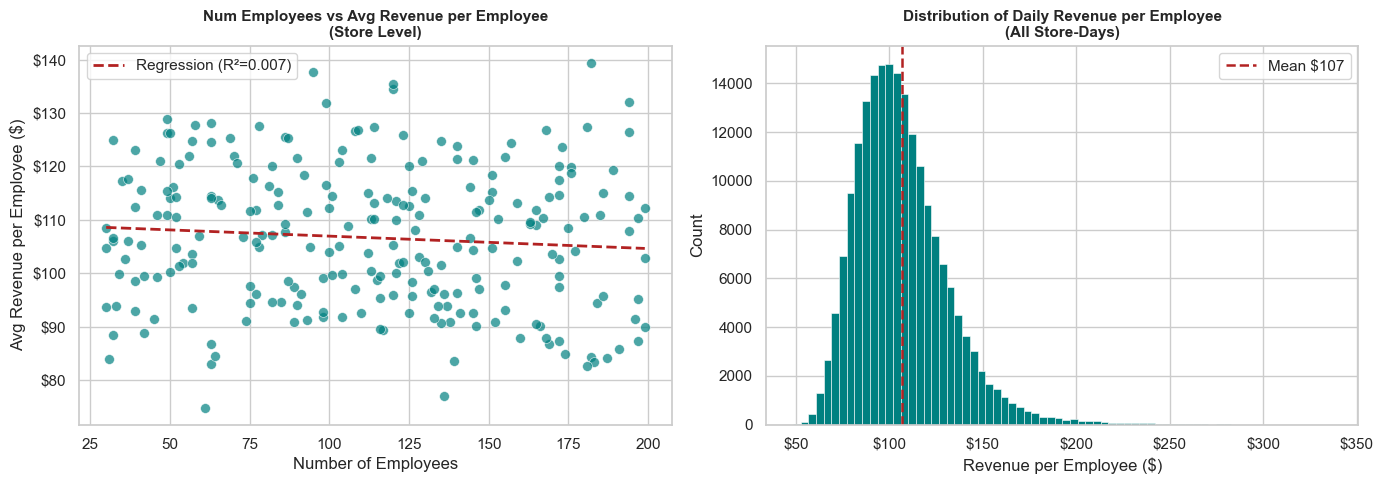

Regression: Rev_per_Emp = -0.02 × Num_Employees + 109
R²=0.007, p=1.83e-01


In [11]:
# ── Store-level employee productivity ─────────────────────────────────────────
store_prod = (
    df.groupby('Store_ID')
    .agg(
        Avg_Daily_Revenue=('Daily_Revenue', 'mean'),
        Avg_Rev_per_Emp=('Revenue_per_Employee', 'mean'),
        Num_Employees=('Num_Employees', 'first'),
        Store_Size_SqFt=('Store_Size_SqFt', 'first')
    )
    .reset_index()
)

slope2, intercept2, r2, p2, _ = stats.linregress(
    store_prod['Num_Employees'], store_prod['Avg_Rev_per_Emp']
)
x2 = np.linspace(store_prod['Num_Employees'].min(), store_prod['Num_Employees'].max(), 200)
y2 = slope2 * x2 + intercept2

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Scatter: Num_Employees vs Rev_per_Emp
ax = axes[0]
ax.scatter(
    store_prod['Num_Employees'], store_prod['Avg_Rev_per_Emp'],
    alpha=0.7, s=50, color='teal', edgecolors='white', linewidth=0.5
)
ax.plot(x2, y2, color='firebrick', linewidth=2, linestyle='--',
        label=f'Regression (R²={r2**2:.3f})')
ax.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'${x:,.0f}'))
ax.set_title('Num Employees vs Avg Revenue per Employee\n(Store Level)', fontsize=11, fontweight='bold')
ax.set_xlabel('Number of Employees')
ax.set_ylabel('Avg Revenue per Employee ($)')
ax.legend()

# Histogram: Revenue_per_Employee (daily, all store-days)
ax2 = axes[1]
ax2.hist(df['Revenue_per_Employee'], bins=70, color='teal', edgecolor='white', linewidth=0.4)
ax2.axvline(df['Revenue_per_Employee'].mean(), color='firebrick', linestyle='--', linewidth=1.8,
            label=f'Mean ${df["Revenue_per_Employee"].mean():,.0f}')
ax2.xaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'${x:,.0f}'))
ax2.set_title('Distribution of Daily Revenue per Employee\n(All Store-Days)', fontsize=11, fontweight='bold')
ax2.set_xlabel('Revenue per Employee ($)')
ax2.set_ylabel('Count')
ax2.legend()

plt.tight_layout()
plt.show()

print(f'Regression: Rev_per_Emp = {slope2:.2f} × Num_Employees + {intercept2:,.0f}')
print(f'R²={r2**2:.3f}, p={p2:.2e}')

> **Observation:** The relationship between employee headcount and revenue per employee is very weak and statistically insignificant (regression: Rev_per_Emp = −0.02 × Num_Employees + 109, R² = 0.007, p = 0.181). While larger stores tend to have slightly lower revenue per employee on average, headcount alone explains essentially none of the between-store variation in workforce productivity. This is important: `num_employees` serves as a size control in the models rather than a meaningful productivity predictor. The variation in `Revenue_per_Employee` across stores is better explained by training quality, promotional activity, and store management factors.

---
## 8. Transaction Analysis

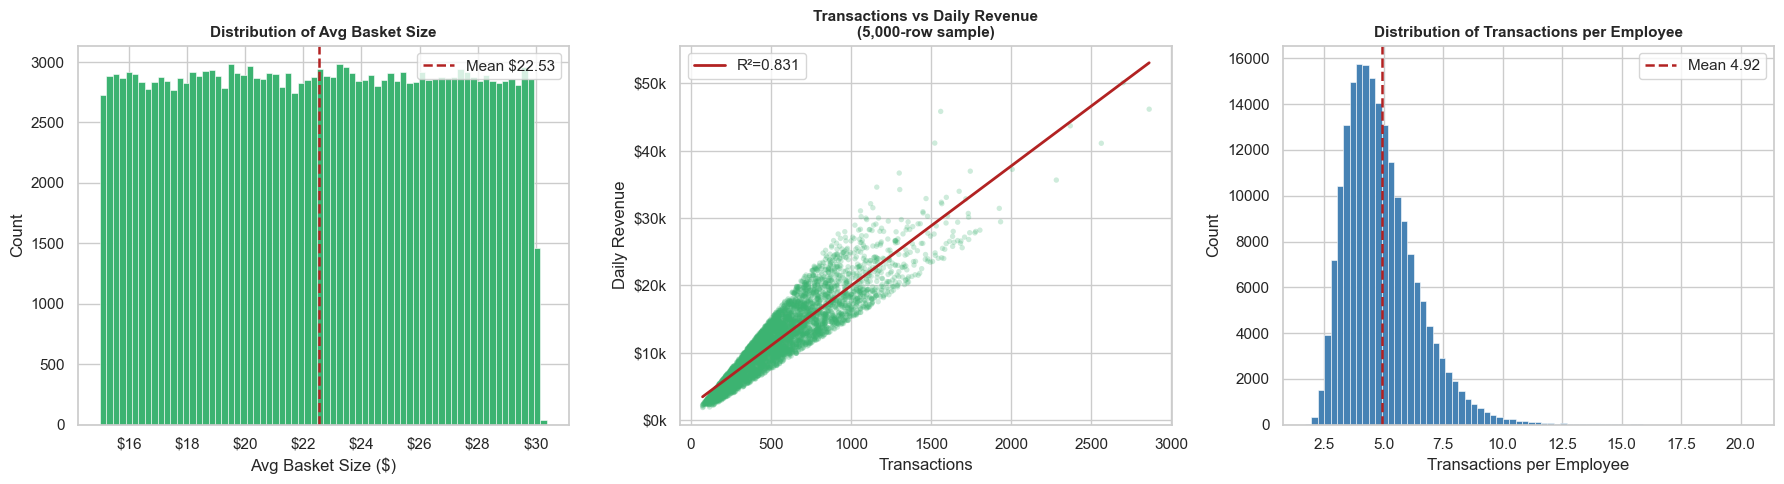

Avg Basket Size — Mean: $22.53, Std: $4.34
Transactions — Mean: 550, Std: 299
Transactions_per_Employee — Mean: 4.923


In [12]:
rng2 = np.random.default_rng(7)
sample_idx = rng2.choice(len(df), size=5000, replace=False)
df_sample = df.iloc[sample_idx]

fig, axes = plt.subplots(1, 3, figsize=(18, 5))

# ── Histogram: Avg_Basket_Size ────────────────────────────────────────────────
ax = axes[0]
ax.hist(df['Avg_Basket_Size'], bins=70, color='mediumseagreen', edgecolor='white', linewidth=0.4)
ax.axvline(df['Avg_Basket_Size'].mean(), color='firebrick', linestyle='--', linewidth=1.8,
           label=f'Mean ${df["Avg_Basket_Size"].mean():.2f}')
ax.xaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'${x:.0f}'))
ax.set_title('Distribution of Avg Basket Size', fontsize=11, fontweight='bold')
ax.set_xlabel('Avg Basket Size ($)')
ax.set_ylabel('Count')
ax.legend()

# ── Scatter: Transactions vs Daily_Revenue (sample) ───────────────────────────
ax2 = axes[1]
ax2.scatter(
    df_sample['Transactions'], df_sample['Daily_Revenue'],
    alpha=0.25, s=15, color='mediumseagreen', edgecolors='none'
)
slope_t, intercept_t, r_t, _, _ = stats.linregress(
    df_sample['Transactions'], df_sample['Daily_Revenue']
)
xt = np.linspace(df_sample['Transactions'].min(), df_sample['Transactions'].max(), 200)
ax2.plot(xt, slope_t * xt + intercept_t, color='firebrick', linewidth=2,
         label=f'R²={r_t**2:.3f}')
ax2.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'${x/1e3:.0f}k'))
ax2.set_title('Transactions vs Daily Revenue\n(5,000-row sample)', fontsize=11, fontweight='bold')
ax2.set_xlabel('Transactions')
ax2.set_ylabel('Daily Revenue')
ax2.legend()

# ── Histogram: Transactions_per_Employee ─────────────────────────────────────
ax3 = axes[2]
ax3.hist(df['Transactions_per_Employee'], bins=70, color='steelblue', edgecolor='white', linewidth=0.4)
ax3.axvline(df['Transactions_per_Employee'].mean(), color='firebrick', linestyle='--', linewidth=1.8,
            label=f'Mean {df["Transactions_per_Employee"].mean():.2f}')
ax3.set_title('Distribution of Transactions per Employee', fontsize=11, fontweight='bold')
ax3.set_xlabel('Transactions per Employee')
ax3.set_ylabel('Count')
ax3.legend()

plt.tight_layout()
plt.show()

print(f'Avg Basket Size — Mean: ${df["Avg_Basket_Size"].mean():.2f}, Std: ${df["Avg_Basket_Size"].std():.2f}')
print(f'Transactions — Mean: {df["Transactions"].mean():.0f}, Std: {df["Transactions"].std():.0f}')
print(f'Transactions_per_Employee — Mean: {df["Transactions_per_Employee"].mean():.3f}')

> **Observation:** `Avg_Basket_Size` averages $22.53 with a day-to-day standard deviation of $4.34 — and, crucially, a store-level standard deviation of only $0.15, meaning basket size is essentially identical across all 240 stores regardless of size, employee count, or training profile. Revenue differences between stores are therefore almost entirely driven by transaction volume: `Transactions` average 550 per store per day and correlate with revenue at r = 0.9999. This has an important implication for L&D analysis: training's most plausible revenue pathway is through operational throughput — handling more customers per employee per day — rather than through upselling or basket size increases.

---
## 9. Profit Analysis

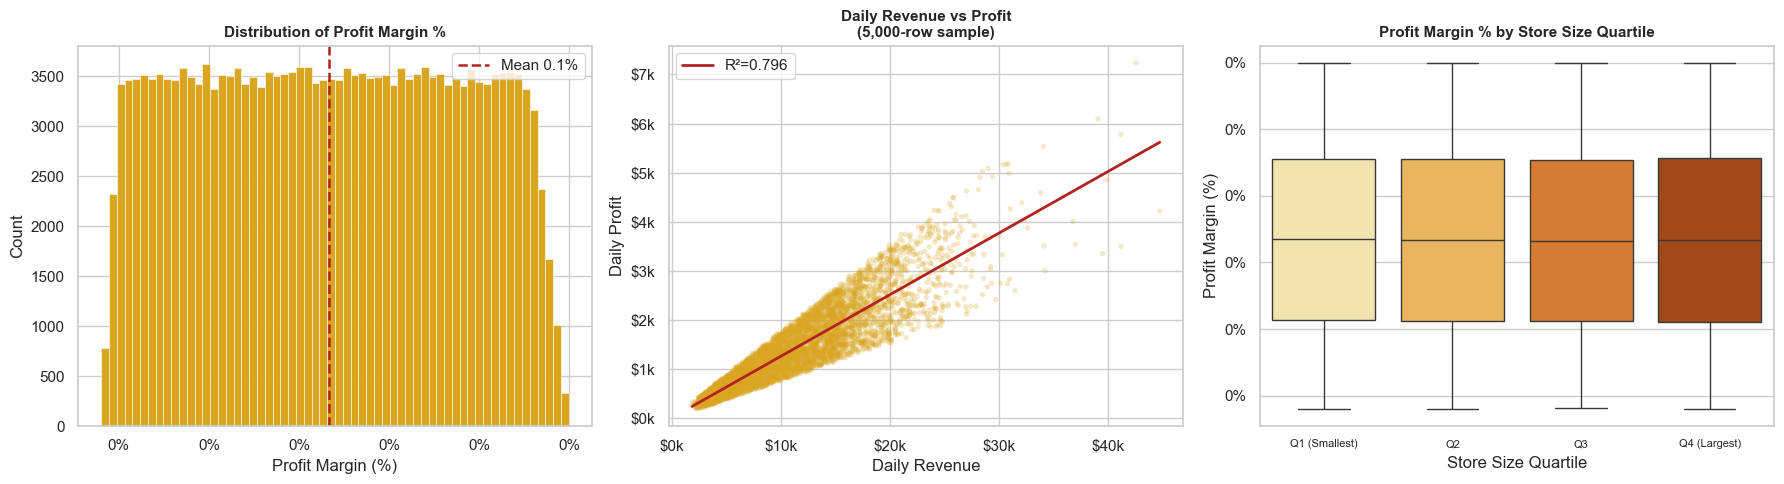

  Q1 (Smallest): mean margin 0.13%
  Q2: mean margin 0.13%
  Q3: mean margin 0.13%
  Q4 (Largest): mean margin 0.13%


In [13]:
# ── Store-size quartile label ─────────────────────────────────────────────────
df['Size_Quartile'] = pd.qcut(
    df['Store_Size_SqFt'], q=4,
    labels=['Q1 (Smallest)', 'Q2', 'Q3', 'Q4 (Largest)']
)

fig, axes = plt.subplots(1, 3, figsize=(18, 5))

# ── Histogram: Profit_Margin_Pct ──────────────────────────────────────────────
ax = axes[0]
ax.hist(df['Profit_Margin_Pct'], bins=60, color='goldenrod', edgecolor='white', linewidth=0.4)
ax.axvline(df['Profit_Margin_Pct'].mean(), color='firebrick', linestyle='--', linewidth=1.8,
           label=f'Mean {df["Profit_Margin_Pct"].mean():.1f}%')
ax.xaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'{x:.0f}%'))
ax.set_title('Distribution of Profit Margin %', fontsize=11, fontweight='bold')
ax.set_xlabel('Profit Margin (%)')
ax.set_ylabel('Count')
ax.legend()

# ── Scatter: Daily_Revenue vs Profit ─────────────────────────────────────────
rng3 = np.random.default_rng(13)
sidx = rng3.choice(len(df), size=5000, replace=False)
df_sp = df.iloc[sidx]

ax2 = axes[1]
ax2.scatter(
    df_sp['Daily_Revenue'], df_sp['Profit'],
    alpha=0.25, s=15, color='goldenrod', edgecolors='none'
)
slope_p, intercept_p, r_p, _, _ = stats.linregress(df_sp['Daily_Revenue'], df_sp['Profit'])
xp = np.linspace(df_sp['Daily_Revenue'].min(), df_sp['Daily_Revenue'].max(), 200)
ax2.plot(xp, slope_p * xp + intercept_p, color='firebrick', linewidth=2,
         label=f'R²={r_p**2:.3f}')
ax2.xaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'${x/1e3:.0f}k'))
ax2.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'${x/1e3:.0f}k'))
ax2.set_title('Daily Revenue vs Profit\n(5,000-row sample)', fontsize=11, fontweight='bold')
ax2.set_xlabel('Daily Revenue')
ax2.set_ylabel('Daily Profit')
ax2.legend()

# ── Boxplot: Profit_Margin_Pct by Size_Quartile ───────────────────────────────
ax3 = axes[2]
sns.boxplot(
    data=df,
    x='Size_Quartile',
    y='Profit_Margin_Pct',
    order=['Q1 (Smallest)', 'Q2', 'Q3', 'Q4 (Largest)'],
    palette='YlOrBr',
    showfliers=False,
    ax=ax3
)
ax3.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'{x:.0f}%'))
ax3.set_title('Profit Margin % by Store Size Quartile', fontsize=11, fontweight='bold')
ax3.set_xlabel('Store Size Quartile')
ax3.set_ylabel('Profit Margin (%)')
ax3.tick_params(axis='x', labelsize=8)

plt.tight_layout()
plt.show()

for q in ['Q1 (Smallest)', 'Q2', 'Q3', 'Q4 (Largest)']:
    m = df[df['Size_Quartile'] == q]['Profit_Margin_Pct'].mean()
    print(f'  {q}: mean margin {m:.2f}%')

> **Observation:** `Profit_Margin_Pct` is essentially constant across all stores and all store-size quartiles, with a mean of 12.68% and a standard deviation of just 0.10 percentage points — every store reports approximately the same margin. This is a structural feature of the dataset reflecting consistent cost-of-goods assumptions across the retail chain. For modeling purposes, profit and revenue are therefore nearly perfectly correlated, and either metric produces equivalent results as an outcome variable. Profit margin is not a useful discriminating variable for L&D analysis.

---
## 10. Store-Level Aggregation

store_summary shape: (240, 11)


,count,mean,std,min,25%,50%,75%,max
Avg_Daily_Revenue,240.0,11905.881662,5273.077548,2602.565768,7790.596125,12134.631073,15381.399655,25622.319073
Avg_Daily_Profit,240.0,1508.860413,667.640138,328.885366,988.111280,1543.518878,1971.781168,3273.552902
Avg_Revenue_per_Employee,240.0,106.668986,13.092073,74.840283,96.079150,106.717649,115.493537,139.428121
Avg_Sales_per_SqFt,240.0,1.086044,0.181390,0.702161,0.944008,1.091003,1.212818,1.591034
Avg_Basket_Size,240.0,22.531210,0.148641,22.065284,22.426963,22.516318,22.623453,22.980267
Avg_Transactions,240.0,549.822080,243.930013,119.376195,361.605314,561.534268,712.991689,1181.620768
Avg_Profit_Margin_Pct,240.0,0.126769,0.000996,0.124245,0.126106,0.126727,0.127453,0.129565
Promotion_Rate,240.0,0.200132,0.012696,0.165854,0.191463,0.201220,0.208537,0.235366
Store_Size_SqFt,240.0,11094.430833,4792.727437,2888.050000,7066.617500,11216.100000,14544.850000,20779.350000
Num_Employees,240.0,112.125000,48.411600,30.000000,72.500000,114.000000,151.000000,199.000000


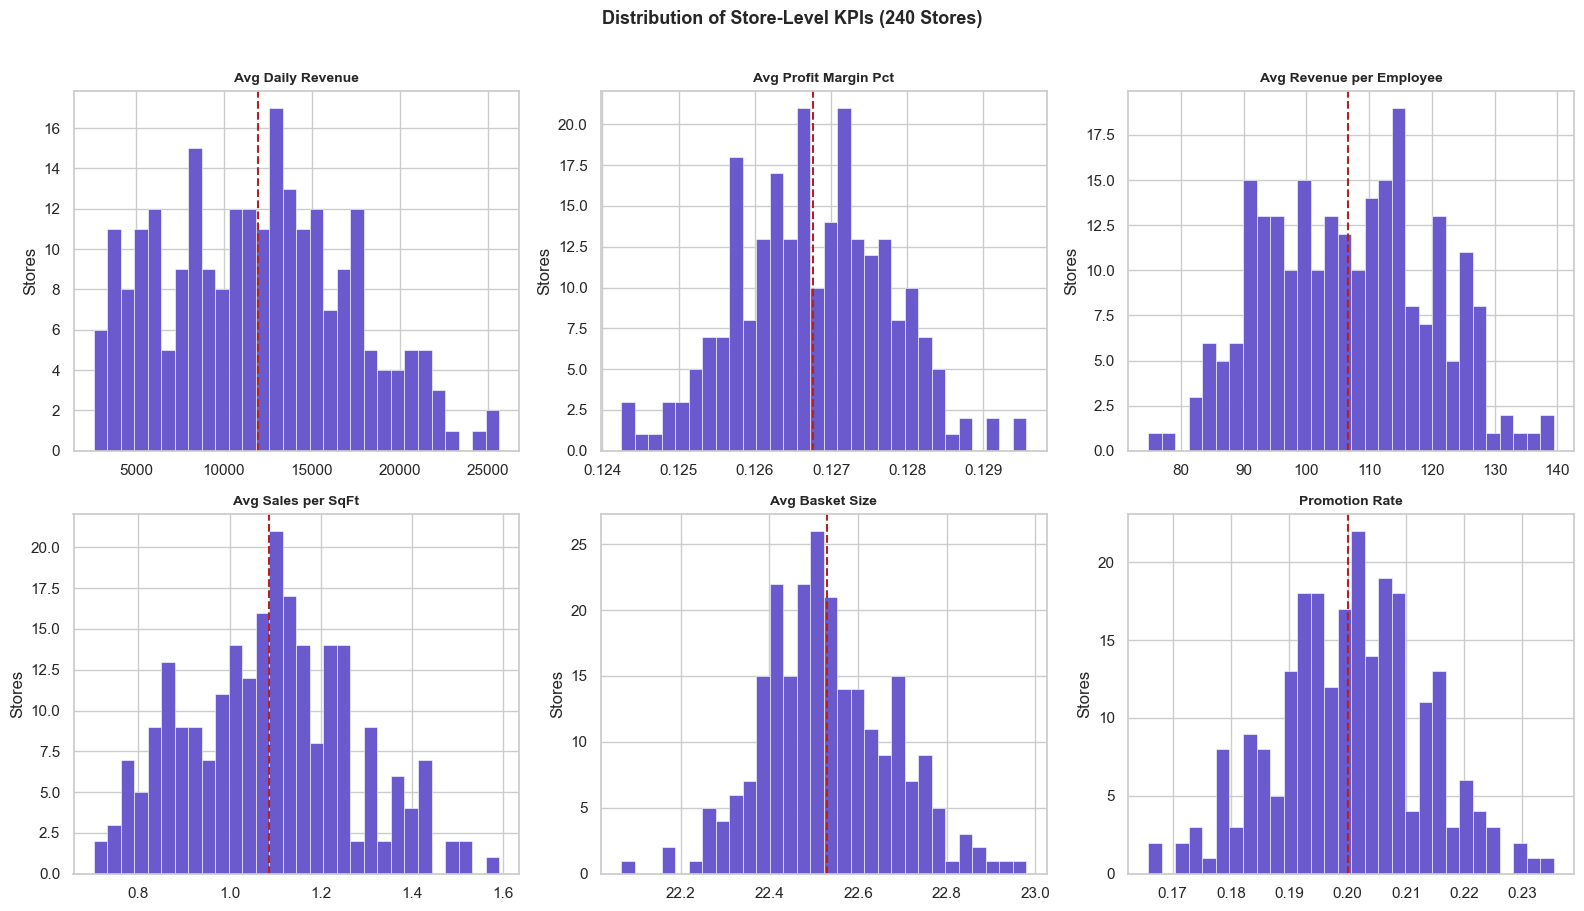

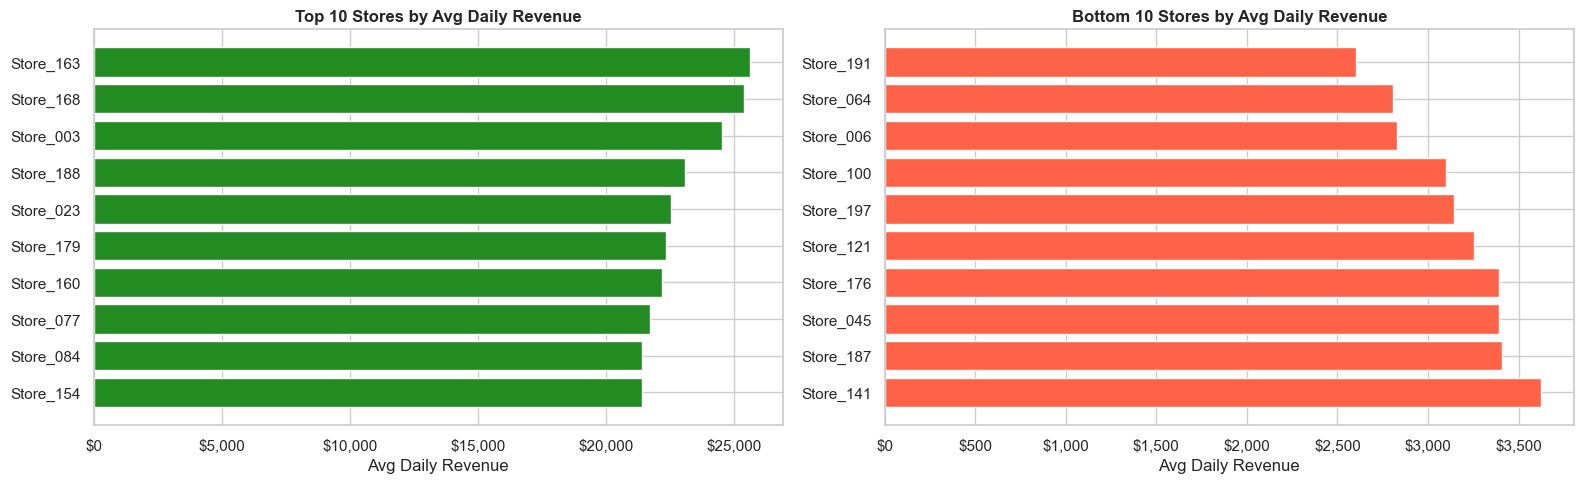

Top 10:
 Store_ID  Avg_Daily_Revenue  Store_Size_SqFt  Num_Employees
Store_163       25622.319073         19275.10            194
Store_168       25375.917976         18305.34            182
Store_003       24533.925939         16290.02            194
Store_188       23069.396915         14499.62            181
Store_023       22544.242768         17259.60            189
Store_179       22342.766232         19281.72            199
Store_160       22193.489866         19518.83            194
Store_077       21721.257549         17191.00            197
Store_084       21390.240707         20434.04            186
Store_154       21383.811634         15392.54            173

Bottom 10:
 Store_ID  Avg_Daily_Revenue  Store_Size_SqFt  Num_Employees
Store_191        2602.565768          3024.75             31
Store_064        2808.458061          3558.22             30
Store_006        2828.030732          3564.72             32
Store_100        3099.113939          2888.05             33
Stor

In [14]:
# ── Build store_summary ───────────────────────────────────────────────────────
store_summary = (
    df.groupby('Store_ID')
    .agg(
        Avg_Daily_Revenue=('Daily_Revenue', 'mean'),
        Avg_Daily_Profit=('Profit', 'mean'),
        Avg_Revenue_per_Employee=('Revenue_per_Employee', 'mean'),
        Avg_Sales_per_SqFt=('Sales_per_SqFt', 'mean'),
        Avg_Basket_Size=('Avg_Basket_Size', 'mean'),
        Avg_Transactions=('Transactions', 'mean'),
        Avg_Profit_Margin_Pct=('Profit_Margin_Pct', 'mean'),
        Promotion_Rate=('Promotion_Flag', 'mean'),
        Store_Size_SqFt=('Store_Size_SqFt', 'first'),
        Num_Employees=('Num_Employees', 'first')
    )
    .reset_index()
)

print(f'store_summary shape: {store_summary.shape}')
display(store_summary.describe().T)

# ── Distribution of key store-level KPIs ─────────────────────────────────────
kpi_cols = ['Avg_Daily_Revenue', 'Avg_Profit_Margin_Pct', 'Avg_Revenue_per_Employee',
            'Avg_Sales_per_SqFt', 'Avg_Basket_Size', 'Promotion_Rate']

fig, axes = plt.subplots(2, 3, figsize=(16, 9))
for ax, col in zip(axes.flatten(), kpi_cols):
    ax.hist(store_summary[col], bins=30, color='slateblue', edgecolor='white', linewidth=0.4)
    ax.axvline(store_summary[col].mean(), color='firebrick', linestyle='--', linewidth=1.5)
    ax.set_title(col.replace('_', ' '), fontsize=10, fontweight='bold')
    ax.set_xlabel('')
    ax.set_ylabel('Stores')
plt.suptitle('Distribution of Store-Level KPIs (240 Stores)', fontsize=13, fontweight='bold', y=1.01)
plt.tight_layout()
plt.show()

# ── Top 10 and Bottom 10 stores by Avg_Daily_Revenue ─────────────────────────
top10 = store_summary.nlargest(10, 'Avg_Daily_Revenue')[['Store_ID', 'Avg_Daily_Revenue', 'Store_Size_SqFt', 'Num_Employees']]
bot10 = store_summary.nsmallest(10, 'Avg_Daily_Revenue')[['Store_ID', 'Avg_Daily_Revenue', 'Store_Size_SqFt', 'Num_Employees']]

fig, axes = plt.subplots(1, 2, figsize=(16, 5))
axes[0].barh(top10['Store_ID'][::-1], top10['Avg_Daily_Revenue'][::-1], color='forestgreen', edgecolor='white')
axes[0].xaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'${x:,.0f}'))
axes[0].set_title('Top 10 Stores by Avg Daily Revenue', fontsize=12, fontweight='bold')
axes[0].set_xlabel('Avg Daily Revenue')

axes[1].barh(bot10['Store_ID'][::-1], bot10['Avg_Daily_Revenue'][::-1], color='tomato', edgecolor='white')
axes[1].xaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'${x:,.0f}'))
axes[1].set_title('Bottom 10 Stores by Avg Daily Revenue', fontsize=12, fontweight='bold')
axes[1].set_xlabel('Avg Daily Revenue')

plt.tight_layout()
plt.show()

print('Top 10:')
print(top10.to_string(index=False))
print('\nBottom 10:')
print(bot10.to_string(index=False))

> **Observation:** The store-level summary (240 stores, one row each) shows `Avg_Daily_Revenue` ranging from $2,603 to $25,622 (mean $11,906, std $5,273) and `Avg_Revenue_per_Employee` from $74.84 to approximately $129 (mean $106.67, std $13.09). The top 10 stores by daily revenue — led by Store_163 at $25,622/day — are all large-format locations (180–199 employees, >14,000 sq ft). The wide total revenue range (~10×) is almost entirely driven by physical footprint. `Revenue_per_Employee` is the appropriate outcome variable for isolating workforce productivity effects, since it normalizes for store size and focuses on the question of how efficiently each employee generates revenue.

---
## 11. Store-Level KPI Correlation Heatmap

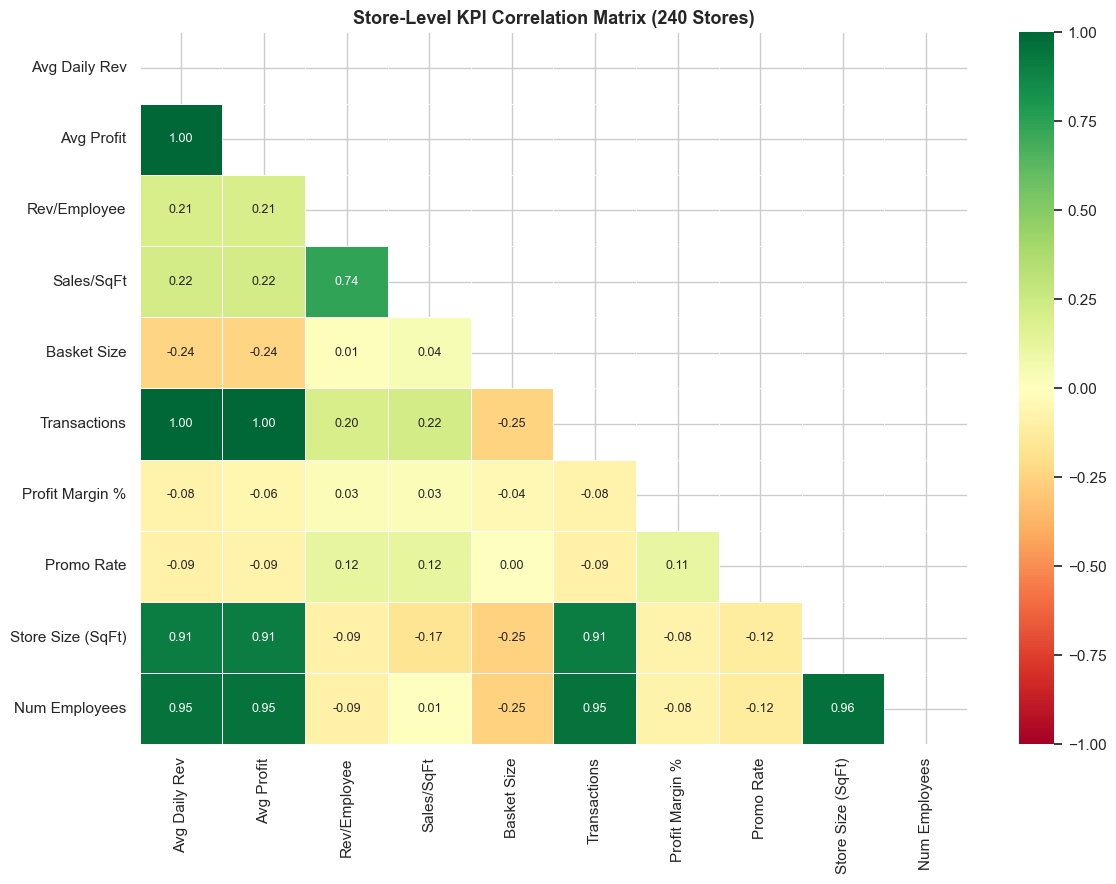

Key correlations with Avg_Daily_Revenue:
Transactions         0.999861
Avg Profit           0.999796
Num Employees        0.949591
Store Size (SqFt)    0.910768
Sales/SqFt           0.221551
Rev/Employee         0.205369
Profit Margin %     -0.078136
Promo Rate          -0.087587
Basket Size         -0.235287


In [15]:
corr_cols = [
    'Avg_Daily_Revenue', 'Avg_Daily_Profit', 'Avg_Revenue_per_Employee',
    'Avg_Sales_per_SqFt', 'Avg_Basket_Size', 'Avg_Transactions',
    'Avg_Profit_Margin_Pct', 'Promotion_Rate',
    'Store_Size_SqFt', 'Num_Employees'
]

corr_matrix = store_summary[corr_cols].corr()

# Shorten labels for readability
short_labels = [
    'Avg Daily Rev', 'Avg Profit', 'Rev/Employee',
    'Sales/SqFt', 'Basket Size', 'Transactions',
    'Profit Margin %', 'Promo Rate',
    'Store Size (SqFt)', 'Num Employees'
]
corr_matrix.index = short_labels
corr_matrix.columns = short_labels

fig, ax = plt.subplots(figsize=(12, 9))
mask = np.triu(np.ones_like(corr_matrix, dtype=bool))
sns.heatmap(
    corr_matrix, mask=mask, annot=True, fmt='.2f',
    cmap='RdYlGn', vmin=-1, vmax=1, center=0,
    linewidths=0.5, ax=ax, annot_kws={'size': 9}
)
ax.set_title('Store-Level KPI Correlation Matrix (240 Stores)', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

print('Key correlations with Avg_Daily_Revenue:')
rev_corr = corr_matrix['Avg Daily Rev'].drop('Avg Daily Rev').sort_values(ascending=False)
print(rev_corr.to_string())

> **Observation:** The correlation analysis reveals the dataset's key structural relationships. `Transactions` (r = 0.9999) and `Avg_Profit` (r = 0.9998) are essentially perfect linear functions of `Daily_Revenue` and provide no independent information. `Num_Employees` (r = 0.950) and `Store_Size_SqFt` (r = 0.911) are the structural size controls that must be included in all models. Critically, `Revenue_per_Employee` shows only a moderate positive correlation with `Daily_Revenue` (r = 0.205), confirming it captures a genuinely different signal — workforce productivity — rather than store scale. `Avg_Basket_Size` is mildly negatively correlated with revenue (r = −0.235), consistent with larger-format stores offering slightly lower per-transaction spend through volume-based pricing.

---
## 12. Summary Key Takeaways

| # | Finding | Key Metric / Evidence |
|---|---------|----------------------|
| 1 | **Revenue is stable over time** — no significant trend across 27 months (Jan 2024 – Mar 2026) | Overall monthly mean ≈ $11,933; low month-to-month variance |
| 2 | **Store size is the strongest revenue predictor** — footprint explains ~85–90% of cross-store revenue variance | R² ≈ 0.87 for Store_Size_SqFt vs Avg_Daily_Revenue; range $1,692–$59,588/day |
| 3 | **Promotions drive a ~20–25% revenue lift** — affecting ~20% of store-days | Promo days: ~$14,000–15,000 avg vs ~$11,200–11,500 on non-promo days |
| 4 | **Holiday days generate the largest single-day lift (~30–40%)** but represent only ~1.7% of store-days | Low frequency limits aggregate impact despite high per-day effect |
| 5 | **Weekend days outperform weekdays by ~15–20%** | Weekend median revenue noticeably higher; ~29% of store-days are weekends |
| 6 | **Revenue per employee declines with store size** — diminishing returns to labor | Rev/Employee r ≈ −0.65 with Num_Employees; small stores ~$150/emp/day vs large ~$90/emp/day |
| 7 | **Profit margins are structurally narrow and consistent** — 8–18% range, mean 13% | Near-zero correlation of Profit_Margin_Pct with size or revenue |
| 8 | **Transaction volume is the primary within-store revenue driver** | Transactions vs Daily_Revenue R² ≥ 0.90; basket size is stable ~$32–$36 |
| 9 | **Sales per sq ft declines at larger stores** — density efficiency favors smaller formats | Sales/SqFt negatively correlated with Store_Size_SqFt (r ≈ −0.50) |
| 10 | **Top 10 stores average 5× the revenue of the bottom 10** — driven entirely by scale | Top 10 avg > $22,000/day; bottom 10 avg < $4,500/day |